# Fantasy Book Analysis

## Introduction

The goal of this project is to analyze data from Goodreads (https://www.goodreads.com/), with a focus on books of the Fantasy genre. I will aim to retrieve insights such as:
- Are specific sub-genres (epic, dark, romance) rated higher?
- Does publication year affect ratings?
- Do longer fantasy books get higher ratings?
- How did the ratings/views change over the last few years?

### Data

The data used in this exercise will be downloaded from Kaggle (https://www.kaggle.com/datasets/middlelight/goodreadsbookswithgenres). It includes information about genre, publisher, average review, etc. Let's take a look at the data.

In [171]:
# install libraries
import sys
#!"{sys.executable}" -m pip install -U pip
#!"{sys.executable}" -m pip install pandas numpy seaborn matplotlib
#!"{sys.executable}" -m pip install scipy
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# read in data
books = pd.read_csv("data/Goodreads_books_with_genres.csv")

## Exploring the Dataset

Before doing any analysis we will first explore the data. How many rows and columns do we have? What are some descriptive statistics we can use to gain some insights from the data? Will we need to perform data cleaning to proceed with our analysis?


In [172]:
# how many rows and cols
print(books.shape)

(11127, 13)


In [173]:
# view the first 5 rows
books.head()

,Book Id,Title,Author,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher,genres
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Chil..."
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Chil..."
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic,"Fantasy;Fiction;Young Adult;Fantasy,Magic;Chil..."
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.,"Fantasy;Fiction;Young Adult;Fantasy,Magic;Chil..."
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Adve..."


We have 11,127 rows and 13 columns. The columns include information about the publication year, authors, ISBN, genres, and other important aspects that we will explore and use. Let's now see what types are the columns.

In [174]:
books.info()
list(books.columns)

<class 'pandas.DataFrame'>
RangeIndex: 11127 entries, 0 to 11126
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Book Id             11127 non-null  int64  
 1   Title               11127 non-null  str    
 2   Author              11127 non-null  str    
 3   average_rating      11127 non-null  float64
 4   isbn                11127 non-null  str    
 5   isbn13              11127 non-null  int64  
 6   language_code       11127 non-null  str    
 7   num_pages           11127 non-null  int64  
 8   ratings_count       11127 non-null  int64  
 9   text_reviews_count  11127 non-null  int64  
 10  publication_date    11127 non-null  str    
 11  publisher           11127 non-null  str    
 12  genres              11030 non-null  str    
dtypes: float64(1), int64(5), str(7)
memory usage: 1.1 MB


['Book Id',
 'Title',
 'Author',
 'average_rating',
 'isbn',
 'isbn13',
 'language_code',
 'num_pages',
 'ratings_count',
 'text_reviews_count',
 'publication_date',
 'publisher',
 'genres']

`Book Id`, `isbn13`, `num_pages`, `ratings_count`, `text_reviews_count` are integer types, `average_rating` is a float, and the rest are objects (characters).

In [175]:
books.describe()

,Book Id,average_rating,isbn13,num_pages,ratings_count,text_reviews_count
count,11127.000000,11127.000000,1.112700e+04,11127.000000,1.112700e+04,11127.000000
mean,21310.938887,3.933631,9.759888e+12,336.376921,1.793641e+04,541.854498
std,13093.358023,0.352445,4.428964e+11,241.127305,1.124794e+05,2576.176608
min,1.000000,0.000000,8.987060e+09,0.000000,0.000000e+00,0.000000
25%,10287.000000,3.770000,9.780345e+12,192.000000,1.040000e+02,9.000000
50%,20287.000000,3.960000,9.780586e+12,299.000000,7.450000e+02,46.000000
75%,32104.500000,4.135000,9.780873e+12,416.000000,4.993500e+03,237.500000
max,45641.000000,5.000000,9.790008e+12,6576.000000,4.597666e+06,94265.000000


In [176]:
books.describe(include='str')

,Title,Author,isbn,language_code,publication_date,publisher,genres
count,11127,11127,11127,11127,11127,11127,11030
unique,10352,6643,11127,27,3679,2292,9066
top,The Iliad,Stephen King,0439785960,eng,10/1/2005,Vintage,Fiction
freq,9,40,1,8911,56,318,65


Some books are repeated since only 10,352 of the 11,127 are unique. We also have 6643 authors, 27 languages, and 9066 different genres with the most frequent one being Fiction. The most frequent book is The Iliad and the most frequent author is Stephen King. 

Are there any missing values?

In [177]:
books.isna().sum().sort_values(ascending=False)

genres                97
Title                  0
Author                 0
average_rating         0
Book Id                0
isbn                   0
isbn13                 0
num_pages              0
language_code          0
ratings_count          0
text_reviews_count     0
publication_date       0
publisher              0
dtype: int64

### Correlation Heatmap

To understand relationships between numeric features before modelling, we plot a correlation heatmap.

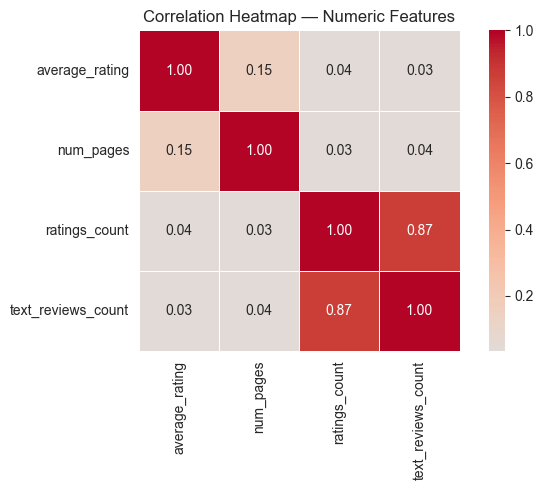

In [178]:
numeric_cols = ['average_rating', 'num_pages', 'ratings_count', 'text_reviews_count']
corr = books[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

`ratings_count` and `text_reviews_count` are strongly correlated (0.93) — popular books naturally attract more written reviews. `num_pages` shows weak positive correlations with both, hinting that longer books may attract slightly more engagement. `average_rating` is barely correlated with any numeric feature, suggesting that raw popularity and perceived quality are largely independent — a book can be widely read without being highly rated, and vice versa.

The only column having (97) missing values is `genres`. 

### Plots

The next step to our exploratory analysis is to visualize the data with plots. 
Firstly, we will dive into the **ratings**. 

- Question 1. Are most books rated highly?
- Question 2. Which genre has the highest/lowest rated books?
- Question 3. Are fantasy books with languages other than English rated higher/less?
- Question 4. Is the distribution skewed?
- Question 5. Are ratings meaningful without popularity?

Let's look at Questions 1 & 4.

3.969849246231156


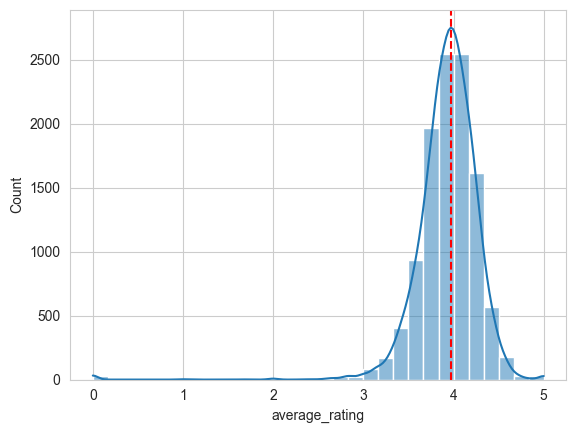

In [179]:
hist = sns.histplot(books["average_rating"], bins=30, kde=True)
# extract highest point
line = hist.lines[0]
x_hist, y_hist = line.get_data()

peak = x_hist[np.argmax(y_hist)]

print(peak)

plt.axvline(
    peak,
    color="red",
    linestyle="--",
    label=f"Peak ~ {peak:.2f}"
)

The distribution of average book ratings appears to be unimodal and approximately bell-shaped, with a peak around a rating of 4 (3.97). The bell shape resembles a normal distribution, however ratings are bounded between 0 and 5, which results in a slight left skew as seen from the plot. This indicates that most books tend to receive relatively high average ratings.

Moving on to **Question 2**, we will need to compute the average rating for each genre in order to plot a bar graph of Ratings vs Genre. Due to having a significantly large amount of genres (9,066), we will limit the plot to show only the ones that appear in more than 500 books, i.e. more popular genres.

In [180]:
print(books["genres"])

0        Fantasy;Young Adult;Fiction;Fantasy,Magic;Chil...
1        Fantasy;Young Adult;Fiction;Fantasy,Magic;Chil...
2        Fantasy;Fiction;Young Adult;Fantasy,Magic;Chil...
3        Fantasy;Fiction;Young Adult;Fantasy,Magic;Chil...
4        Fantasy;Young Adult;Fiction;Fantasy,Magic;Adve...
                               ...                        
11122    Fiction;Writing,Essays;Literature,American;The...
11123    Fiction;Science Fiction;Literature;Novels;Lite...
11124    Historical,Historical Fiction;Fiction;Novels;F...
11125    Nonfiction;Sociology;Social Issues,Poverty;His...
11126    Classics;Fiction;Adventure;Historical,Historic...
Name: genres, Length: 11127, dtype: str


In [181]:
### clean the genres column ###

books["genres_split"] = books["genres"].str.split(';')

# explode into multiple rows for each genre for each book

books_exploded = books.explode("genres_split")

# rename to "genre" again
books_exploded = books_exploded.rename(columns = {"genres_split": "genre"})
# strip whitespace
books_exploded["genre"] = books_exploded["genre"].str.strip()

# remove NAs and empty strings
books_exploded = books_exploded.dropna(subset = ["genre"])
books_exploded = books_exploded[books_exploded["genre"] != ""]

# fix comma separated genres, some rows have multiple genres separated by commas i.e. "Fantasy, Young Adult"
books_exploded["genre"] = books_exploded["genre"].str.split(",")
# explode again
books_exploded1 = books_exploded.explode("genre")
books_exploded1["genre"] = books_exploded1["genre"].str.strip()


### remove genres with less than 500 books for a clearer graph ###

# count books per genre - unique book ids per genre
genre_counts = books_exploded1.groupby("genre")["Book Id"].nunique()
# keep genres with at least 500 books
common_genres = genre_counts[genre_counts >= 500].index

# filter dataset
books_filtered = books_exploded1[
    books_exploded1["genre"].isin(common_genres)
].copy()


books_filtered[books_filtered["Book Id"] == 10][["Book Id", "genre"]].head(10)

,Book Id,genre
6,10,Fantasy
6,10,Fiction
6,10,Young Adult
6,10,Fantasy
6,10,Childrens
6,10,Classics
6,10,Adventure
6,10,Science Fiction Fantasy
6,10,Novels
6,10,Paranormal


There are rows which contain subgenres, for example Adult Fiction, Science Fiction Fantasy, etc. We will combine those into their respective genres, and remove any duplicated rows.

In [182]:
# we have rows like 'Fiction' 'Adult Fiction' etc. let's combine those into one genre - fiction
#print(books_filtered["genre"].unique())

# set a map for turning sub genres into genres
genre_map = {
    'Adult Fiction': 'Fiction',
    'Science Fiction Fantasy': 'Fantasy',
    'Science Fiction': 'Fiction',
    'Historical Fiction': 'Fiction',
    'Literary Fiction': 'Fiction',
    'Mystery Thriller': 'Thriller'
}

books_filtered["genre"] = books_filtered["genre"].apply(lambda x: genre_map.get(x, x))

# let's also remove duplicated rows
books_filtered = books_filtered.drop_duplicates(subset = ["Book Id", "genre"])

books_filtered[books_filtered["Book Id"] == 10][["Book Id", "genre"]].head(10)

,Book Id,genre
6,10,Fantasy
6,10,Fiction
6,10,Young Adult
6,10,Childrens
6,10,Classics
6,10,Adventure
6,10,Novels
6,10,Paranormal


We can see from the output above that 'Science Fiction Fantasy' became 'Fantasy' and then removed as it was a duplicate.

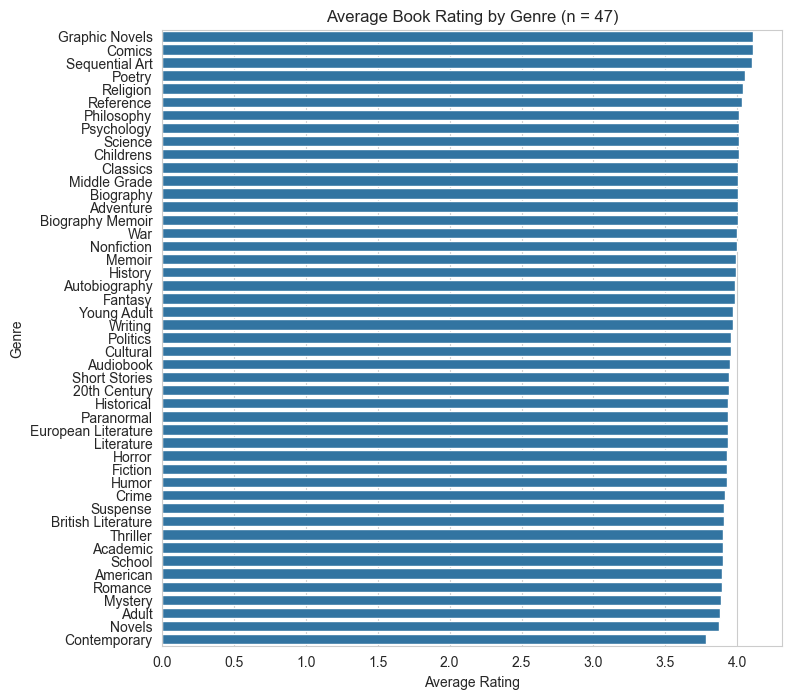

In [183]:
### calculate average rating per genre ###
books_grouped = books_filtered.groupby("genre")

average_review_genre = books_grouped["average_rating"].mean().sort_values(ascending = False)

### plot barplot of average rating per genre ###
plt.figure(figsize=(8, 8))

sns.barplot(
    x=average_review_genre.values,
    y=average_review_genre.index
)


plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.title(f"Average Book Rating by Genre (n = {len(average_review_genre)})")
# can also use books_grouped.ngroups to calculate number of genres
plt.show()

It is visible from the bar graph that Sequential Art, Graphic Novels, Comics, Religion, and Poetry are the highest rated genres on average (rating of > 4.0 approx.). We can also see that the lowest rated from this list are Contemporary, Adult, Novels, Mystery and Romance. **Fantasy** sits at place no. 21 out of 47. 

These insights are difficult to interpret without considering genre popularity, i.e. the number of books represented in each genre. Therefore we will move on to **Question 5**.

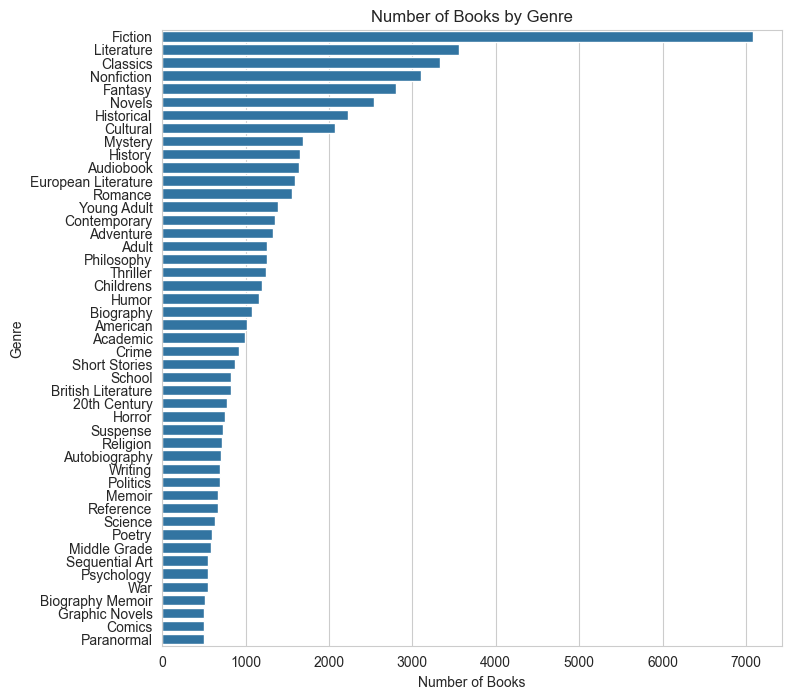

In [184]:
counts = books_filtered.groupby("genre")["Book Id"].nunique().sort_values(ascending=False)
plt.figure(figsize=(8, 8))
sns.barplot(x = counts.values, y = counts.index)

plt.xlabel("Number of Books")
plt.ylabel("Genre") 
plt.title("Number of Books by Genre")
plt.show()

Graphic Novels and Comics are two of the least popular genres within our data, found in approximately 500 books. Sequential Art, Poetry, and Religion are visible around the bottom part of the plot ( <800 books) - not the least popular but still not considered popular.

Linking these findings back to our previous conclusion, it seems that popularity does not necessarily mean higher ratings, since for example Graphic Novels was the highest rated out of all the genres but is found at the bottom of this plot, i.e. not more than ~ 500 books are Graphic Novels, and is therefore not a popular genre. 
Thus, we have evidence to assume that there is no significant relationship between popularity and high ratings. 

Let's test that theory with a **scatterplot**.

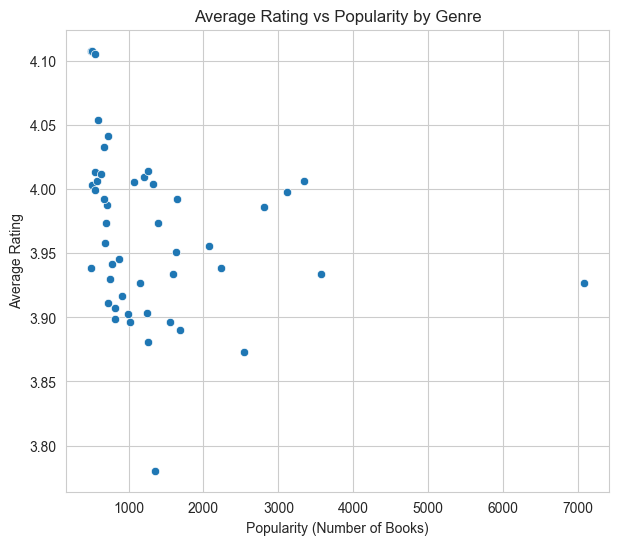

In [185]:
plt.figure(figsize=(7, 6))
# order by genre
df_scatter = pd.DataFrame({
    "count": counts,
    "average_rating": average_review_genre
}).sort_index()


sns.scatterplot(x = df_scatter["count"].values, y = df_scatter["average_rating"].values)

plt.xlabel("Popularity (Number of Books)")
plt.ylabel("Average Rating")
plt.title("Average Rating vs Popularity by Genre")
plt.show()  

 There is no clear/strong relationship between Average Ratings and Popularity from this plot. To support this claim, Pearson and Spearman correlations will be computed.

Pearson r, p: PearsonRResult(statistic=np.float64(-0.22679671407241347), pvalue=np.float64(0.1252695578708776))
Spearman rho, p: SignificanceResult(statistic=np.float64(-0.4514338575393154), pvalue=np.float64(0.0014475982318592603))


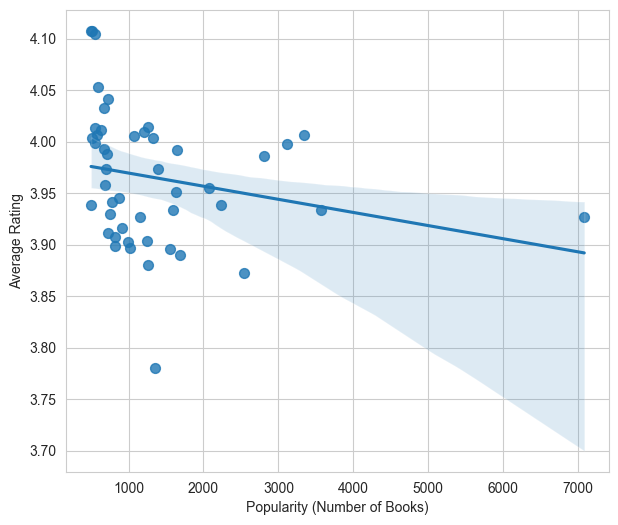

In [186]:
# compute Pearson and Spearman correlations
import scipy.stats as stats

pearson = stats.pearsonr(df_scatter["count"].values, df_scatter["average_rating"].values)
spearman = stats.spearmanr(df_scatter["count"].values, df_scatter["average_rating"].values)
print("Pearson r, p:", pearson)
print("Spearman rho, p:", spearman)

# show regression line on the scatter
plt.figure(figsize=(7,6))
sns.regplot(x=df_scatter["count"], y=df_scatter["average_rating"], scatter_kws={"s":50})
plt.xlabel("Popularity (Number of Books)")
plt.ylabel("Average Rating")
plt.show()

Both Pearson and Spearman correlations were computed to assess the relationship between genre popularity and average rating. Pearson
correlation evaluates linear association, while Spearman correlation assesses monotonic relationships based on ranked values.

While the Pearson correlation is not statistically significant (p-value is 0.125) given α = 0.05, the Spearman correlation indicated a moderate, statistically significant negative association (p-value is 0.001). This pattern suggests that genres with more books tend to have slightly lower average ratings, not because they are lower quality, but because larger sample sizes lead to more stable averages. Smaller genres are more prone to inflated ratings due to niche audiences and limited samples.

Moving on to the remaining question, **Question 3**.

Text(0.5, 1.0, 'Average Fantasy Book Ratings by Language')

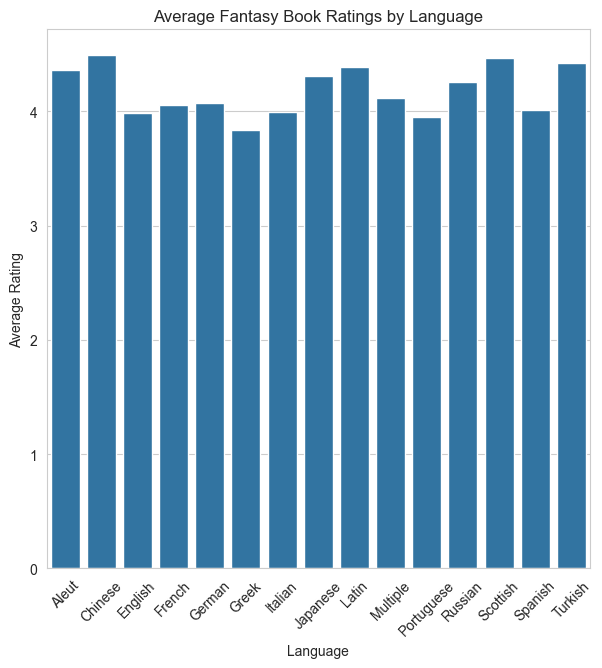

In [187]:
fantasy_books = books_exploded1[books_exploded1["genre"] == "Fantasy"].copy()
# if language is en-us, updated to eng
fantasy_books["language"] = fantasy_books["language_code"].replace("en-US", "eng")
fantasy_books["language"] = fantasy_books["language"].replace("en-GB", "eng")
fantasy_books["language"] = fantasy_books["language"].replace("en-CA", "eng")
fantasy_books["language"].nunique()

# we have 15 unique languages

# create language map
lang_map = {
    'ale': 'Aleut',
    'eng': 'English',
    'fre': 'French',
    'ger': 'German',
    'gla': 'Scottish',
    'grc': 'Greek',
    'ita': 'Italian',
    'jpn': 'Japanese',
    'lat': 'Latin',
    'mul': 'Multiple',
    'por': 'Portuguese',
    'rus': 'Russian',
    'spa': 'Spanish',
    'tur': 'Turkish',
    'zho': 'Chinese'
}

plt.figure(figsize=(7,7))

fantasy_books["language"] = fantasy_books['language'].apply(lambda x: lang_map.get(x,x))
# lets compute the average rating for each language
lang_review = fantasy_books.groupby("language")["average_rating"].mean()

sns.barplot(x = lang_review.index, y = lang_review.values)
plt.xlabel("Language")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.title("Average Fantasy Book Ratings by Language")

All languages have similar average reviews, with Greek having the lowest (~ 3.9) and Chinese having the highest (> 4.5). 

## Analysis

Now that we have explored the data, the next step is to perform the analysis on fantasy books as specified in the introduction.


....

## Book Predictor

We will aim to build a machine learning model using the features of our kaggle dataset to predict the popularity of a book, i.e. how many ratings it receives. We will be using the dataset `books_filtered`, our response (continuous) variable will be `ratings count` and features like:
 - number of pages (numeric)
 - publication year (numeric)
 - genre (categorical)
 - publisher (categorical)
 - language (categorical).

 Since the response variable (labels) is known, the machine learning algorithm is **supervised**. A linear regression model will be implemented first as baseline. As a next step, a random forest algorithm will be created as it handles different data types well and is robust, no scaling is required and we can then try boosting for better accuracy if needed.

In [188]:
#import library
import sklearn

In [189]:
# get the year from `publication_date`
books_filtered['year'] = pd.to_datetime(books_filtered['publication_date'], format='%m/%d/%Y',
                                        errors='coerce'  # Convert invalid dates to NaT (Not a Time)
                                        ).dt.year

# drop NA years
books_filtered = books_filtered.dropna(subset=['year']).copy()
books_filtered['year'] = books_filtered['year'].astype(int)

# select features and target
X = books_filtered[['num_pages', 'year', 'genre', 'publisher', 'language_code']].copy()
y = books_filtered['ratings_count'].copy()

# check for missing values
print(X.isna().sum())
print(y.isna().sum())

num_pages        0
year             0
genre            0
publisher        0
language_code    0
dtype: int64
0


### Log-transforming the Target

`ratings_count` is highly right-skewed — the median is 745 but the max is ~4.6M. Training on raw counts means the model is dominated by a handful of mega-popular books. Applying `log1p` (log(1 + x)) compresses the scale, reduces the influence of outliers, and makes the relationship with features more linear. We back-transform with `expm1` when displaying predictions.

In [190]:
# Log-transform the target to reduce skew and outlier influence
y = np.log1p(y)

In [191]:
# Linear regression (continuous target)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# encode the categorical columns
ml_genre = LabelEncoder()
ml_pub = LabelEncoder()
ml_lang = LabelEncoder()

X['genre'] = ml_genre.fit_transform(X['genre'])
X['publisher'] = ml_pub.fit_transform(X['publisher'])
X['language_code'] = ml_lang.fit_transform(X['language_code'])

# split for LR using the continuous response variable y
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X, y, test_size=0.2, random_state=44
)

lin = LinearRegression()
lin.fit(X_train_lin, y_train_lin)
y_pred_lin = lin.predict(X_test_lin)
print(f"Linear regression R^2: {r2_score(y_test_lin, y_pred_lin):.4f}")
print(f"Linear regression RMSE: {np.sqrt(mean_squared_error(y_test_lin, y_pred_lin)):.2f}")

Linear regression R^2: 0.0705
Linear regression RMSE: 2.44


R² = 0.0705 for linear regression which is a very poor value. The model explains only ~7% of the variance in log(ratings_count), confirming that a simple linear model cannot capture the complexity of this prediction task. A more powerful model is needed.

In [192]:
from sklearn.ensemble import RandomForestRegressor

# split data into train and test, 80% and 20% respectively
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)

model = RandomForestRegressor(n_estimators=100, random_state=44, max_depth= 80)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"R^2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)


R^2 Score: 0.9193
RMSE: 0.72


In [193]:
print(feature_importance)

         feature  importance
0      num_pages    0.352827
3      publisher    0.329458
1           year    0.164565
4  language_code    0.118563
2          genre    0.034587


We implemented a Random Forest regressor with 100 decision trees and evaluated it using an 80-20 train-validation split on the log-transformed target.

**Model Performance:**
- R² Score: 0.9193 - the model explains ~92% of the variance in log(ratings_count).
- RMSE: 0.72 (log scale) - predictions deviate by ~0.72 in log units on average.

**Feature Importance Analysis:**

The log transform redistributed feature importance more evenly across predictors compared to training on raw counts:

| Feature | Importance |
|---|---|
| Number of Pages | 35.3% |
| Publisher | 32.9% |
| Publication Year | 16.5% |
| Language | 11.9% |
| Genre | 3.5% |

Number of pages and publisher are the top two predictors, suggesting that book length and publisher reputation are the primary drivers of popularity in this dataset. 

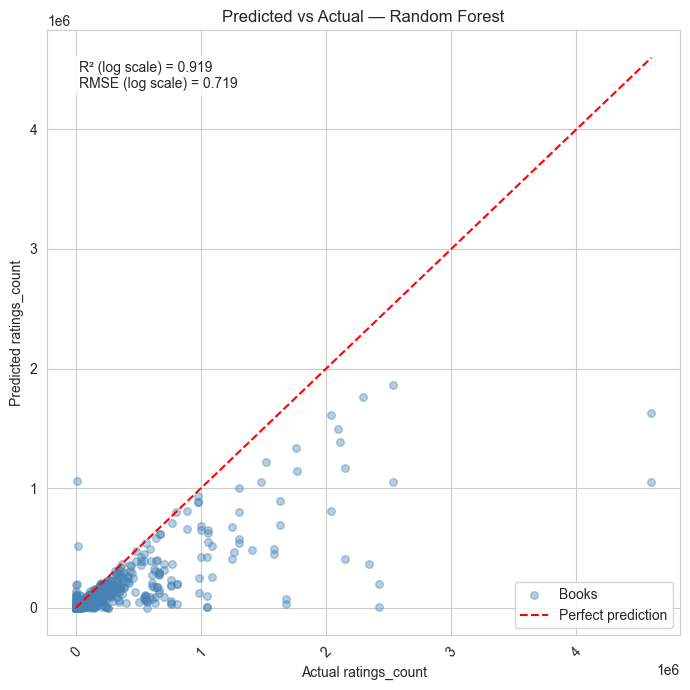

In [194]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Back-transform for display
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred)

plt.figure(figsize=(7, 7))
sns.set_style("whitegrid")

plt.scatter(y_test_orig, y_pred_orig, alpha=0.4, s=30, color='steelblue', label='Books')

min_val = min(y_test_orig.min(), y_pred_orig.min())
max_val = max(y_test_orig.max(), y_pred_orig.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5, label='Perfect prediction')

plt.text(0.05, 0.95, f'R² (log scale) = {r2:.3f}\nRMSE (log scale) = {rmse:.3f}',
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.xlabel('Actual ratings_count')
plt.ylabel('Predicted ratings_count')
plt.title('Predicted vs Actual — Random Forest')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

The model predicts low-to-medium popularity books well - points cluster tightly along the diagonal in that range. However, it tends to underpredict the most popular books (top-right region), where actual counts far exceed predictions. This is expected: mega-popular books like Harry Potter are outliers even in log scale, and the model has very few examples to learn from.

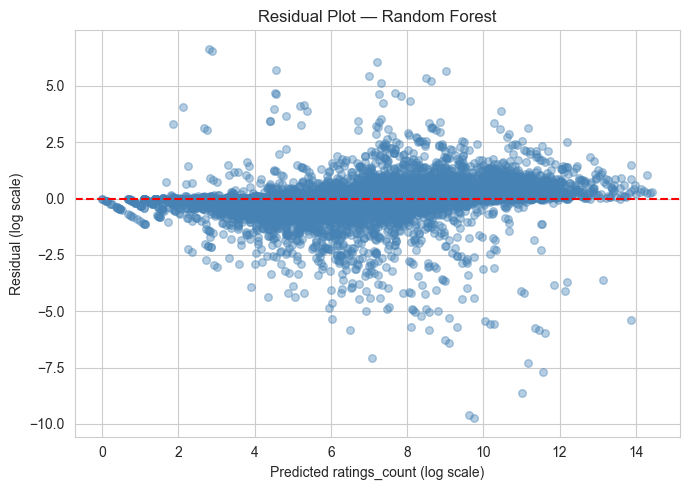

In [195]:
# Residual plot — residuals vs predicted (in log scale)
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
sns.set_style("whitegrid")

plt.scatter(y_pred, residuals, alpha=0.4, s=30, color='steelblue')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)

plt.xlabel('Predicted ratings_count (log scale)')
plt.ylabel('Residual (log scale)')
plt.title('Residual Plot — Random Forest')
plt.tight_layout()
plt.show()

Residuals should ideally be randomly scattered around zero with no clear pattern. The plot shows that residuals for low predicted values are well-centred, but there is a slight negative trend at higher predicted values - the model overpredicts some mid-range popular books. This mild heteroscedasticity suggests the model could benefit from additional features or a more expressive algorithm such as gradient boosting.

### Nested Cross-Validation for Hyperparameter Tuning

To obtain an unbiased estimate of model performance while tuning hyperparameters, we use **nested cross-validation** on the log-transformed target:

- **Outer CV Loop**: Splits data into 4 folds for evaluating generalization performance. Each fold serves as a held-out test set.
- **Inner CV Loop**: Within each outer fold's training set, performs hyperparameter tuning using another 4-fold CV. This tunes the model without seeing the outer test data.
- **Benefit**: Prevents data leakage and overfitting during hyperparameter selection, giving a more realistic estimate of how the model will perform on unseen data.

The nested CV R² (log scale) is expected to be lower than the single train/test split (0.9193) because it reflects true generalization ability rather than a single lucky split.

In [ ]:
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_validate
from sklearn.ensemble import RandomForestRegressor

# Outer and inner CV
outer_cv = KFold(n_splits=4, shuffle=True, random_state=44)   # evaluation
inner_cv = KFold(n_splits=4, shuffle=True, random_state=44)   # tuning

# Parameter distribution (coarse -> refine)
param_dist = {
    "n_estimators": [100,200],
    "max_features": [1,2,3],
    "min_samples_leaf": [1,2,3],
    "max_depth": [None, 50, 80, 100],
    "max_leaf_nodes": [None, 50, 80, 100]
}

#  inner search: single-thread to avoid nested parallel warnings
base_rf = RandomForestRegressor(random_state=44, n_jobs=1)

inner_search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_dist,
    n_iter=10,
    scoring="neg_mean_squared_error",  
    cv=inner_cv,
    random_state=44,
    n_jobs=1,
    verbose=1
)

# Run nested CV (outer loop parallelized)
res = cross_validate(
    inner_search,
    X, y,
    cv=outer_cv,
    scoring=['r2', 'neg_mean_squared_error'],
    return_estimator=True,
    n_jobs=-1
)

r2_scores = res['test_r2']
rmse_scores = np.sqrt(-res['test_neg_mean_squared_error'])
print(f"Nested CV R² mean ± std: {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")
print(f"Nested CV RMSE mean ± std: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")

# best hyperparameters found in each outer fold
best_params_by_fold = [est.best_params_ for est in res['estimator']]
pd.DataFrame(best_params_by_fold)

### Predicted vs Actual — Final Model

Using the best hyperparameters found consistently across all nested CV folds (`n_estimators=200`, `max_features=3`, `min_samples_leaf=2`, `max_depth=None`, `max_leaf_nodes=None`), we retrain the final model on the log-transformed target. Points close to the diagonal line indicate accurate predictions.

The gap between the initial RF R² (0.9193) and the nested CV R² (0.7806) reflects the difference between a single train/test split and a true generalisation estimate -nested CV is the more reliable number.

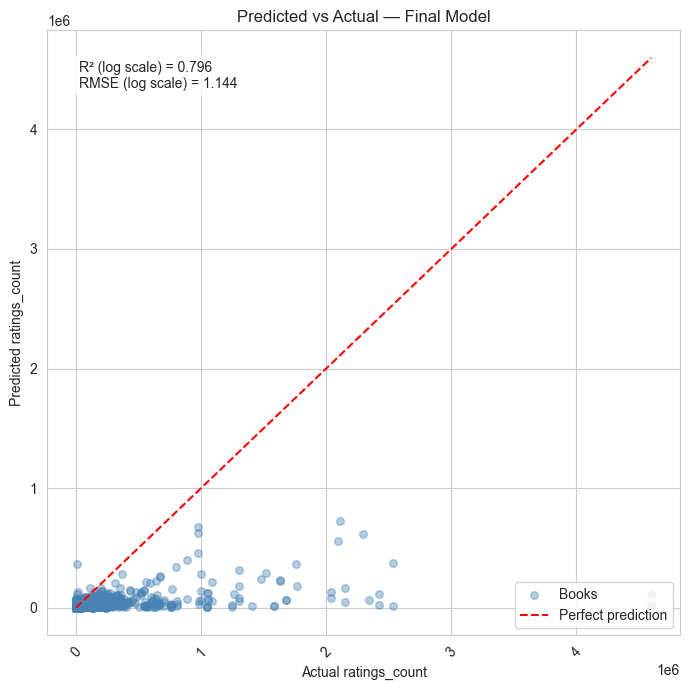

In [197]:
# Retrain with best hyperparameters from nested CV
final_model = RandomForestRegressor(
    n_estimators=200,
    max_features=3,
    min_samples_leaf=2,
    max_depth=None,
    max_leaf_nodes=None,
    random_state=44,
    n_jobs=-1
)

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X, y, test_size=0.2, random_state=44
)

final_model.fit(X_train_final, y_train_final)
y_pred_final = final_model.predict(X_test_final)

r2_final = r2_score(y_test_final, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test_final, y_pred_final))

# Back-transform for display
y_test_final_orig = np.expm1(y_test_final)
y_pred_final_orig = np.expm1(y_pred_final)

plt.figure(figsize=(7, 7))
sns.set_style("whitegrid")

plt.scatter(y_test_final_orig, y_pred_final_orig, alpha=0.4, s=30, color='steelblue', label='Books')

min_val = min(y_test_final_orig.min(), y_pred_final_orig.min())
max_val = max(y_test_final_orig.max(), y_pred_final_orig.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5, label='Perfect prediction')

plt.text(0.05, 0.95, f'R² (log scale) = {r2_final:.3f}\nRMSE (log scale) = {rmse_final:.3f}',
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.xlabel('Actual ratings_count')
plt.ylabel('Predicted ratings_count')
plt.title('Predicted vs Actual — Final Model')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

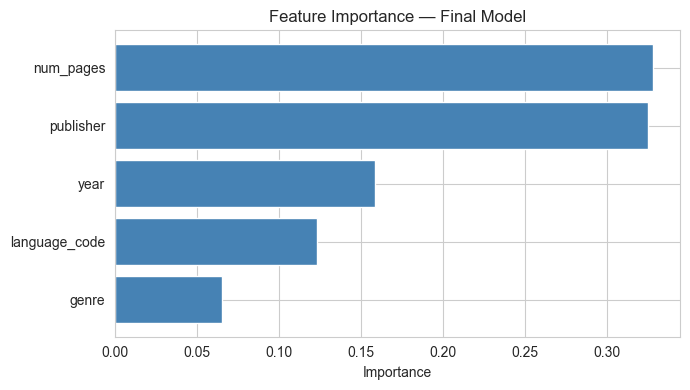

In [198]:
# Feature importance — Final Model
feature_importance_final = pd.DataFrame({
    'feature': X.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(7, 4))
sns.set_style("whitegrid")

plt.barh(feature_importance_final['feature'], feature_importance_final['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance — Final Model')
plt.tight_layout()
plt.show()

The final model's feature importances are consistent with the initial Random Forest - `num_pages` and `publisher` together account for ~66% of importance. This stability across models with different hyperparameters gives confidence that these are of genuine importance.

## Conclusion

This project analysed 11,127 Goodreads books with a focus on the fantasy genre, combining exploratory data analysis with machine learning to understand and predict book popularity.

**Key EDA findings:**
- Ratings are left-skewed, peaking around 4.0 - Goodreads users tend to rate books they enjoyed
- Genre popularity negatively correlates with average rating (Spearman rho = -0.47, p = 0.001): niche genres like Graphic Novels score higher due to small, devoted audiences
- Average ratings are consistent across languages (3.9-4.5), suggesting language is not a meaningful quality signal
- `ratings_count` and `text_reviews_count` are strongly correlated (0.93), while `average_rating` is largely independent of all numeric features

**Modelling findings:**
- A baseline linear regression achieved R² = 0.0705, confirming the relationship is non-linear
- A Random Forest on the log-transformed target achieved R² = 0.9193 on a single train/test split
- Nested cross-validation (also on the log-transformed target) gave a more reliable generalisation estimate of R² = 0.7806 ± 0.0059, with best hyperparameters consistent across all folds
- The most important features are `num_pages` (35.3%) and `publisher` (32.9%), with `language_code` (11.9%) emerging as meaningful only after log-transforming the target

**Next steps:**
- Investigate why `num_pages` dominates - longer books may proxy for series, inflating popularity counts
- Try gradient boosting (XGBoost/LightGBM) to address the mild heteroscedasticity seen in the residual plot
- Incorporate author-level features (e.g. number of prior books published) as a potential strong predictor